<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/Decide_where_to_land_your_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decide where to land your drone**

* 400 total images are available here[https://drive.google.com/drive/folders/14VdHmRA3p3A2M1ITm-qTjD40jNk1U9ei] (semantic drone dataset ref.)
  * Some picture has been discarded, but there is correspondence in the folders
* The idea is to build a network to perform segmentation on the images
  * UNet is a good choice, but different architectures can be tested and compared (FCN, SegNet, ResNet, …)
  * The number of layers and parameters is something you have to tune
  * 90% accuracy can be achieved with 150 epochs, training is reasonably fast
* Once the segmentation is performed, use an algorithm or ML to spot where to land your drone
  * Far away from trees, houses, etc
* Suggestion:
  * The GPU memory on CoLab is 15GB. Minimizing the I/O helps during the training phase
  * Use the tensorflow dataset following the pets example to load the data in batches on the GPU
  * Reduce the image size and normalize the masks

**Report & instruction:** https://elearning.unimib.it/pluginfile.php/2123111/mod_resource/content/2/Lecture%2014%20%281%29%20%281%29.pdf

**Workflow:**
1. First try to build a Unet or ResUnet CNN architecture
2. Validate and check the accuracy
3. Then try to use a pretrained model for encoder and Unet upsampling for decoder (Keras pretrained model is a good option)
4. Validate and check the second model if it perform better the first bench mark

In [27]:
# import packages
from google.colab import drive
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchsummary import summary
import random

In [26]:
# set the device to make sure using the right processor
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'You are runing on [{device}] device')

You are runing on [cpu] device


In [2]:
# connect to the drive to so you can get access to the your dataset
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
# dataset path
path = "/content/drive/MyDrive/Environment/Segmentation/dataset"

In [4]:
# Check inside the dataset directory how many file and folders are there
for dirpath, dirnames, filenames in os.walk(path):
    print(f'There are {len(filenames)} files and {len(dirnames)} directories in [{dirpath}]')
    for dirname in dirnames:
        sub_path = os.path.join(dirpath, dirname)
        for dirpath_c, dirnames_c, filenames_c in os.walk(sub_path):
          print(f'There are {len(filenames_c)} files and {len(dirnames_c)} directories in [{dirpath_c}]')

There are 1 files and 3 directories in [/content/drive/MyDrive/Environment/Segmentation/dataset]
There are 400 files and 0 directories in [/content/drive/MyDrive/Environment/Segmentation/dataset/label_images_semantic]
There are 400 files and 0 directories in [/content/drive/MyDrive/Environment/Segmentation/dataset/original_images]
There are 400 files and 0 directories in [/content/drive/MyDrive/Environment/Segmentation/dataset/RGB_color_image_masks]


In [5]:
# list all the images from the original_images directory later on we can use them
org_imgs = os.listdir(os.path.join(path, 'original_images'))
print(f'There are {len(org_imgs)} images in [original_images] directory')

There are 400 images in [original_images] directory


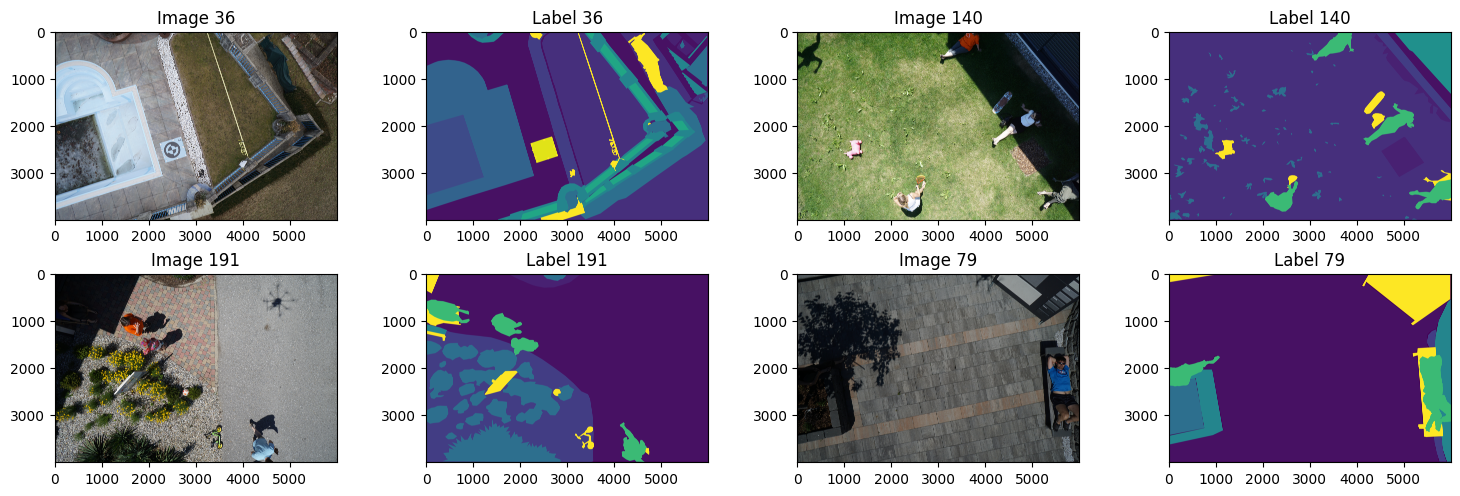

In [ ]:
# reading images and labels by index later
def get_img_label(idx):
  img_path = org_imgs[idx]
  img = Image.open(os.path.join(path, 'original_images', img_path))
  label = Image.open(os.path.join(path, 'label_images_semantic', f'{img_path.split('.')[0]}.png'))
  return img, label

# plot some random images with the labes side by side
fig, ax = plt.subplots(2, 4, figsize=(15, 5))

# First
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[0][0].imshow(img)
ax[0][0].set_title(f'Image {random_idx}')
ax[0][1].imshow(label)
ax[0][1].set_title(f'Label {random_idx}')

# Second
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[0][2].imshow(img)
ax[0][2].set_title(f'Image {random_idx}')
ax[0][3].imshow(label)
ax[0][3].set_title(f'Label {random_idx}')

# Third
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[1][0].imshow(img)
ax[1][0].set_title(f'Image {random_idx}')
ax[1][1].imshow(label)
ax[1][1].set_title(f'Label {random_idx}')

# Fourth
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[1][2].imshow(img)
ax[1][2].set_title(f'Image {random_idx}')
ax[1][3].imshow(label)
ax[1][3].set_title(f'Label {random_idx}')

plt.tight_layout()

In [6]:
# split the dataset in training (70%), validation (20%), and tesing (10%)
generator = torch.Generator().manual_seed(0) # keep the randomnes constant for the development and testing
training_imgs, validation_imgs, testing_imgs = torch.utils.data.random_split(org_imgs, [0.7, 0.2, 0.1])
print(f'{len(training_imgs)} images for training \n{len(validation_imgs)} images for validation \n{len(testing_imgs)} images for testinng.')
print(f'Total number of images: {len(org_imgs)}')

280 images for training 
80 images for validation 
40 images for testinng.
Total number of images: 400


In [7]:
# Create a class to load the dataset
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, data_dir, img_list, transform=None):
    self.data_dir = data_dir
    self.img_list = img_list
    self.transform = transform

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    img = Image.open(os.path.join(self.data_dir, 'original_images', self.img_list[index])).convert("RGB")
    mask = Image.open(os.path.join(self.data_dir, 'label_images_semantic', f'{self.img_list[index].split('.')[0]}.png')).convert("L")
    if self.transform:
      img, mask = self.transform(img, mask)
    return img, mask

In [ ]:
# Get the mean and std of feature images
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = MyDataset(path, training_imgs, transform=transform)

loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

mean = 0.
std = 0.
total_images = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)  # flatten H,W

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4441, 0.4431, 0.4013])
Std: tensor([0.1898, 0.1837, 0.1954])


In [8]:
# Add some data augmentaion to the datasets
IMG_SIZE = 224
gl_mean = [0.4441, 0.4431, 0.4013]
gl_std = [0.1898, 0.1837, 0.1954]
def train_transform(img, mask):
    # Resize
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE))
    # Random horizontal flip
    if random.random() > 0.5:
        img = TF.hflip(img)
        mask = TF.hflip(mask)
    # Random rotation
    angle = random.uniform(-10, 10)
    img = TF.rotate(img, angle)
    mask = TF.rotate(mask, angle)
    # Convert to tensor
    img = TF.to_tensor(img)
    mask = TF.to_tensor(mask)
    # Normalize ONLY image
    img = TF.normalize(
        img,
        mean=gl_mean,
        std=gl_std
    )
    return img, mask

test_transformer = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=gl_mean, std=gl_std)
    ])

In [9]:
# Load the trainin, validation and testing dataset
# This might take 12 minuts in the first attempt
train_data = MyDataset(path, training_imgs, train_transform)
val_data = MyDataset(path, validation_imgs, test_transformer)
test_data = MyDataset(path, testing_imgs, test_transformer)
len(train_data), len(val_data), len(test_data)

(280, 80, 40)

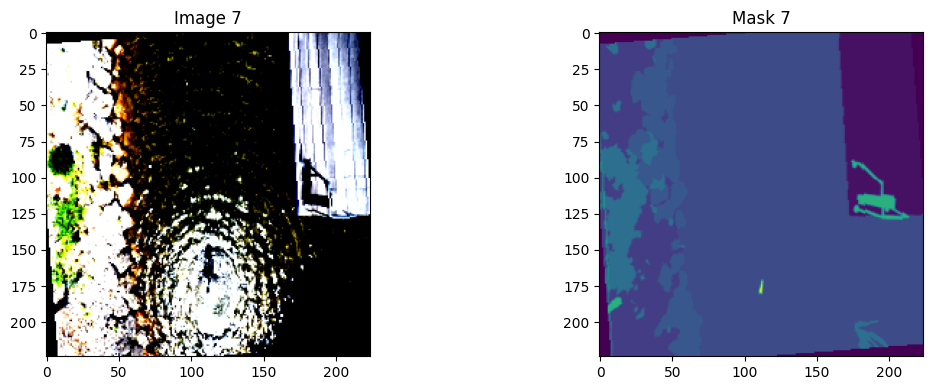

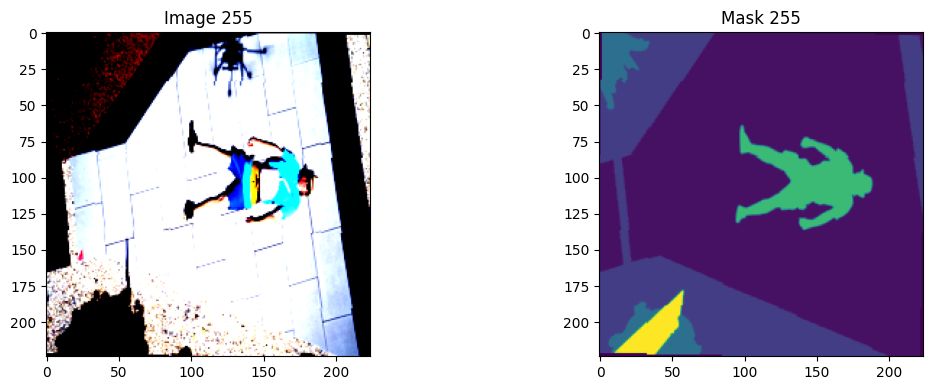

In [ ]:
# plot a random training augmented image and the mask to make sure it's working fine
for i in range(2):
  _, ax = plt.subplots(1, 2, figsize=(12, 4))
  idx = np.random.randint(0, len(train_data))
  img, label = train_data.__getitem__(idx)
  ax[0].imshow(img.permute(1, 2, 0))
  ax[0].set_title(f"Image {idx}")
  ax[1].imshow(label.permute(1, 2, 0))
  ax[1].set_title(f"Mask {idx}")


  plt.tight_layout()

In [14]:
# Create a data loader for training, validation, and testing
batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_data,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2,
                                               pin_memory=True, # speeds up the transfer of data from CPU to GPU
                                               drop_last=True)
val_dataloader = torch.utils.data.DataLoader(val_data,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2,
                                               pin_memory=True,
                                               drop_last=False)

test_dataloader = torch.utils.data.DataLoader(test_data,
                                               batch_size=batch_size,
                                               shuffle=False,
                                               num_workers=2,
                                               pin_memory=True,
                                               drop_last=False)
print(f"""There are {len(train_dataloader)} training batches
{len(val_dataloader)} validation batches
{len(test_dataloader)} testing batches""")


There are 8 training batches
3 validation batches
2 testing batches


In [68]:
# build the double conve
class DoubleConve_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
     self.double_conv = nn.Sequential(
         nn.Conv2d(in_c, out_c, 3, padding=1, stride=1),
         nn.ReLU(),
         nn.Conv2d(out_c, out_c, 3, padding=1, stride=1),
         nn.ReLU()
     )
  def forward(self, x):
    out = self.double_conv(x)
    return out

In [69]:
# Create downsampling block
class Downsampling_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
     self.double_conv = DoubleConve_block(in_c, out_c)
     self.max = nn.MaxPool2d(2)
     self.dropout = nn.Dropout2d(0.3)

  def forward(self, x):
    f = self.double_conv(x)
    out = self.max(f)
    out = self.dropout(out)
    return f, out

In [70]:
# Create upsampling block
class Upsampling_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
    #  upsample
     self.convt = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
     self.drop = nn.Dropout(0.3)
     self.double_block = DoubleConve_block(out_c*2, out_c)
  def forward(self, x, skip):
    up = self.convt(x)
    # concatenate
    concat = torch.cat([up, skip], dim=1)
    # dropout
    out = self.drop(concat) # (out_c + out_c, out_c)
    # Conv2D twice with ReLU activation
    out = self.double_block(out)
    return out


In [73]:
# Build the U-Net Model
class U_Net(nn.Module):
  def __init__(self):
    super(U_Net, self).__init__()
    # input
    # self.input = nn.Conv2d(3, 64, 3, padding=1) # (B, C, H, W)
    # Downsampling
    self.down1 = Downsampling_block(3, 64)
    self.down2 = Downsampling_block(64, 128)
    self.down3 = Downsampling_block(128, 256)
    self.down4 = Downsampling_block(256, 512)
    # Bottelneck
    self.bottleneck = DoubleConve_block(512, 1024)
    # Upsampling
    self.up6 = Upsampling_block(1024, 512)
    self.up7 = Upsampling_block(512, 256)
    self.up8 = Upsampling_block(256, 128)
    self.up9 = Upsampling_block(128, 64)
    self.output = nn.Conv2d(64, 3, kernel_size=1)
  def forward(self, x):
    # x = self.input(x)
    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = self.down1(x)
    # 2 - downsample
    f2, p2 = self.down2(p1)
    # 3 - downsample
    f3, p3 = self.down3(p2)
    # 4 - downsample
    f4, p4 = self.down4(p3)

    # 5 - bottleneck
    bottleneck = self.bottleneck(p4)

    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = self.up6(bottleneck, f4) # f4 is the skip connection
    # 7 - upsample
    u7 = self.up7(u6, f3)
    # 8 - upsample
    u8 = self.up8(u7, f2)
    # 9 - upsample
    u9 = self.up9(u8, f1)
    # outputs
    output = self.output(u9)
    return output

In [74]:
u_net = U_Net().to(device)
summary(u_net, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           1,792
              ReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
              ReLU-4         [-1, 64, 128, 128]               0
 DoubleConve_block-5         [-1, 64, 128, 128]               0
         MaxPool2d-6           [-1, 64, 64, 64]               0
         Dropout2d-7           [-1, 64, 64, 64]               0
Downsampling_block-8  [[-1, 64, 128, 128], [-1, 64, 64, 64]]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
             ReLU-10          [-1, 128, 64, 64]               0
           Conv2d-11          [-1, 128, 64, 64]         147,584
             ReLU-12          [-1, 128, 64, 64]               0
DoubleConve_block-13          [-1, 128, 64, 64]               0
        MaxPool2d-14      